# Notebook 1: SNP Data Cleaning

This notebook imports the SNP feature matrix created with the Pipeline and performs preliminary data exploration and cleaning. 

**Overview:**
1. Load SNP genotypes and resistance phenotypes
2. Merge data on sample name
3. Remove low-prevalence SNPs (<2%)
4. Remove uninformative SNPs (>98% frequency)
6. Remove duplicate SNPs (identical across all samples)
7. Linkage disequilibrium pruning (remove highly correlated SNPs)
8. Select SNPs associated with resistance (chi-square test)
9. Save cleaned feature matrix ready for ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler

## **0. Helper function**
The function **parse_resistance_profile** is used to extract the resistance profiles from the genome_metadata.csv file.

In [2]:
def parse_resistance_profile(profile_str):
    """
    Parse resistance profile string into individual antibiotic phenotypes.
    
    Current format: "Resistant to X, Y; Susceptible to A, B; Intermediate to C; Not determined: D"
    Returns: dict with antibiotic: phenotype (R/S/I/ND)
    """
    phenotypes = {}
    
    if pd.isna(profile_str):
        return phenotypes
    
    # Split by semicolon to get phenotype groups
    parts = str(profile_str).split(';')
    
    for part in parts:
        part = part.strip()
        if not part:
            continue
            
        # Determine phenotype
        if part.startswith('Resistant to'):
            phenotype = 'R'
            antibiotics_str = part.replace('Resistant to', '').strip()
        elif part.startswith('Susceptible to'):
            phenotype = 'S'
            antibiotics_str = part.replace('Susceptible to', '').strip()
        elif part.startswith('Intermediate to'):
            phenotype = 'I'
            antibiotics_str = part.replace('Intermediate to', '').strip()
        elif part.startswith('Not determined'):
            phenotype = 'ND'
            antibiotics_str = part.replace('Not determined:', '').strip()
        else:
            continue
        
        # Split antibiotics by comma and add to dict
        antibiotics = [ab.strip() for ab in antibiotics_str.split(',')]
        for antibiotic in antibiotics:
            if antibiotic:
                phenotypes[antibiotic] = phenotype
    
    return phenotypes

## **1: Load and preprocess the data**
We first want to load the feature matrix (containing detected SNPs for all the strains) and a metadata file containing the resistance profile for all strains. 
We will then make sure that the strains in the feature matrix have a corresponding resistance profile.

In [3]:
# Load SNP feature matrix (rows = samples, columns = SNPs)
snps_df = pd.read_csv('snps.tsv', sep='\t', index_col=0)
print(f"SNP feature matrix shape: {snps_df.shape}")
print(f"\nFirst 5 samples x 10 SNPs:")
snps_df.iloc[:5, :10]

SNP feature matrix shape: (227, 78850)

First 5 samples x 10 SNPs:


,snp__NZ_AP028077.1_128_G_C,snp__NZ_AP028077.1_134_C_G,snp__NZ_AP028077.1_390_T_C,snp__NZ_AP028077.1_1158_G_A,snp__NZ_AP028077.1_1534_G_A,snp__NZ_AP028077.1_1549_G_A,snp__NZ_AP028077.1_2720_TG_CA,snp__NZ_AP028077.1_2721_G_A,snp__NZ_AP028077.1_2737_AG_A,snp__NZ_AP028077.1_2762_C_T
sample,,,,,,,,,,
SRR3404582,0,1,0,0,1,0,0,0,1,0
SRR3404597,0,1,0,0,1,0,0,0,1,0
SRR3404599,0,1,0,0,1,0,0,0,1,0
SRR5927082,0,0,0,1,0,0,0,0,1,0
SRR6075123,0,0,0,0,0,0,0,0,1,0


In [4]:
# Load sample info (resistance phenotypes) from metadata tsv file
# Expected columns: genome_name, source, species, resistance_profile, sra_accession
resistances = pd.read_csv('genome_metadata.csv')

print(f"Sample metadata shape: {resistances.shape}")
print(f"Columns: {list(resistances.columns)}")

# Parse resistance profiles into a dictionary with antibiotic phenotypes
parsed_resistances = resistances['resistance_profile'].apply(parse_resistance_profile)
print(parsed_resistances)

# Convert list of dictionaries into a DataFrame
resistances_df = pd.json_normalize(parsed_resistances)
print(resistances_df)

# Add sample name (sra_accession) to data frame and set is as index
resistances_df['sra_accession'] = resistances['sra_accession'].values
resistances_df = resistances_df.set_index('sra_accession')

print(f"Parsed phenotype data shape: {resistances_df.shape}")
print(f"Available antibiotics: {list(resistances_df.columns)}")
print("First few rows:")
resistances_df.head()

Sample metadata shape: (283, 5)
Columns: ['genome_name', 'source', 'species', 'resistance_profile', 'sra_accession']
0      {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'ND'}
1       {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
2       {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
3       {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
4       {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
                             ...                        
278    {'MEM': 'R', 'CAZ': 'ND', 'SXT': 'ND', 'AMC': ...
279    {'SXT': 'R', 'MEM': 'R', 'CAZ': 'ND', 'AMC': '...
280    {'MEM': 'R', 'CAZ': 'ND', 'SXT': 'ND', 'AMC': ...
281    {'MEM': 'R', 'CAZ': 'ND', 'SXT': 'ND', 'AMC': ...
282    {'CAZ': 'R', 'SXT': 'ND', 'AMC': 'ND', 'MEM': ...
Name: resistance_profile, Length: 283, dtype: object
    SXT AMC CAZ  IPM  MEM   TZ TMEM/SMX
0     R   S   S   ND  NaN  NaN      NaN
1     R   S   S    S  NaN  NaN      NaN
2     R   S   S    S  NaN  NaN      NaN
3     R   S   S    S  NaN  NaN      NaN
4  

,SXT,AMC,CAZ,IPM,MEM,TZ,TMEM/SMX
sra_accession,,,,,,,
SRR27387708,R,S,S,ND,NaN,NaN,NaN
SRR27387706,R,S,S,S,NaN,NaN,NaN
SRR27387705,R,S,S,S,NaN,NaN,NaN
SRR27387702,R,S,S,S,NaN,NaN,NaN
SRR27387701,R,S,S,S,NaN,NaN,NaN


In [5]:
# Find common samples between SNP data and resistance profile data and keep only common samples
# Start by removing duplicate entries
resistances_df = resistances_df.loc[~resistances_df.index.duplicated(keep='first')]
snps_df = snps_df.loc[~snps_df.index.duplicated(keep='first')]

# Find common samples
common_samples = snps_df.index.intersection(resistances_df.index)
print(f"\nCommon samples: {len(common_samples)} out of {len(snps_df)} SNP samples and {len(resistances_df)} samples with known resistance profiles")

# Keep only samples with both SNP and phenotype data
snps_df = snps_df.loc[common_samples].copy()
resistances_df = resistances_df.loc[common_samples].copy()

print(f"\nAligned data shape:")
print(f"SNPs: {snps_df.shape}")
print(f"Resistance profiles: {resistances_df.shape}")


Common samples: 227 out of 227 SNP samples and 262 samples with known resistance profiles

Aligned data shape:
SNPs: (227, 78850)
Resistance profiles: (227, 7)


## **2: Choose Target Antibiotic**

The data contains information for several antibiotics. For this project, we will focus on one antibiotic for the initial modeling.

In [6]:
# Check available antibiotics and their distributions
print(resistances_df.columns)
# These are example names - adjust to your actual column names
antibiotic_cols = [col for col in resistances_df.columns]
print(antibiotic_cols)

print("Antibiotic phenotype distributions:")

for antibiotic in antibiotic_cols:
    print(f"\n{antibiotic}:")
    dist = resistances_df[antibiotic].value_counts()
    print(dist)
    print(f"Missing: {resistances_df[antibiotic].isnull().sum()}")

Index(['SXT', 'AMC', 'CAZ', 'IPM', 'MEM', 'TZ', 'TMEM/SMX'], dtype='str')
['SXT', 'AMC', 'CAZ', 'IPM', 'MEM', 'TZ', 'TMEM/SMX']
Antibiotic phenotype distributions:

SXT:
SXT
R    123
S    104
Name: count, dtype: int64
Missing: 0

AMC:
AMC
S     217
ND      5
R       5
Name: count, dtype: int64
Missing: 0

CAZ:
CAZ
S     219
ND      3
Name: count, dtype: int64
Missing: 5

IPM:
IPM
S     142
ND     77
Name: count, dtype: int64
Missing: 8

MEM:
MEM
S     7
ND    3
R     3
Name: count, dtype: int64
Missing: 214

TZ:
Series([], Name: count, dtype: int64)
Missing: 227

TMEM/SMX:
Series([], Name: count, dtype: int64)
Missing: 227


In [7]:
# Select antibiotic for ML prediction 
target_antibiotic = 'SXT'

In [8]:
# Create binary target: S=0 (susceptible), R=1 (resistant)
SXT_profile = resistances_df[target_antibiotic].copy()

# Remove ND 
valid_samples = SXT_profile[SXT_profile.isin(['S', 'R'])].index
print(f"Valid samples: {len(valid_samples)} out of {len(SXT_profile)}")

# Filter feature matrix
snps_df = snps_df.loc[valid_samples]

# Convert resistance profile to int (1=Resistant, 0=Susceptible)
SXT_profile = (SXT_profile.loc[valid_samples] == 'R').astype(int) 

print(SXT_profile.head())
print(f"\nFinal dataset:")
print(f"Samples: {len(snps_df)}")
print(f"SNPs: {snps_df.shape[1]}")
print(f"SXT resistance distribution:\n{SXT_profile.value_counts()}")

Valid samples: 227 out of 227
SRR3404582    1
SRR3404597    1
SRR3404599    1
SRR5927082    0
SRR6075123    0
Name: SXT, dtype: int64

Final dataset:
Samples: 227
SNPs: 78850
SXT resistance distribution:
SXT
1    123
0    104
Name: count, dtype: int64


## **3: Data cleaning**
Now that we have our feature matrix and the resistance profile for all of the strains, let's perform some preliminary data cleaning on the feature matrix. 

### **3.1 Remove Low-Prevalence SNPs**
SNPs present in <1% or >99% of samples don't provide predictive power.
- less than 1%: too rare, just noise
- more than 98%: nearly fixed, no variation to predict from

In [9]:
# Calculate allele frequencies
snp_prevalence = snps_df.sum(axis=0) / len(snps_df) * 100  # % of samples with SNP of interest

print(f"SNP prevalence statistics:")
print(f"Mean: {snp_prevalence.mean():.2f}%")
print(f"Median: {snp_prevalence.median():.2f}%")
print(f"Min: {snp_prevalence.min():.2f}%")
print(f"Max: {snp_prevalence.max():.2f}%")

# Count SNPs in different frequency bins
print(f"\nSNP frequency distribution:")
print(f"<2%: {(snp_prevalence < 2).sum()}")
print(f"2-98%: {((snp_prevalence >= 2) & (snp_prevalence <= 98)).sum()}")
print(f">98%: {(snp_prevalence > 98).sum()}")

SNP prevalence statistics:
Mean: 14.60%
Median: 2.64%
Min: 0.44%
Max: 99.12%

SNP frequency distribution:
<2%: 36087
2-98%: 42562
>98%: 201


In [10]:
# Filter: keep SNPs present in 5-95% of samples
mask = (snp_prevalence >= 2) & (snp_prevalence <= 98)
snps_filt = snps_df[snps_df.columns[mask]].copy()

print(f"After frequency filtering:")
print(f"Original SNPs: {snps_df.shape[1]}")
print(f"Filtered SNPs: {snps_filt.shape[1]}")
print(f"Removed: {snps_df.shape[1] - snps_filt.shape[1]} ({(snps_df.shape[1] - snps_filt.shape[1])/snps_df.shape[1]*100:.1f}%)")

After frequency filtering:
Original SNPs: 78850
Filtered SNPs: 42562
Removed: 36288 (46.0%)


### **3.2: Remove Duplicate SNPs**

If two SNPs are identical across all samples, keep only one.

In [11]:
# Find duplicate SNPs (identical patterns)
# Transpose to compare SNPs instead of samples
snps_T = snps_filt.T
duplicates = snps_T.duplicated(keep='first')

print(f"Duplicate SNPs found: {duplicates.sum()}")

# Remove duplicate SNPs (keep first occurrence)
snps_unique = snps_filt.loc[:, ~duplicates].copy()

print(f"\nAfter removing duplicates:")
print(f"  SNPs before: {snps_filt.shape[1]}")
print(f"  SNPs after: {snps_unique.shape[1]}")
print(f"  Removed: {snps_filt.shape[1] - snps_unique.shape[1]} duplicate SNPs")

Duplicate SNPs found: 5672

After removing duplicates:
  SNPs before: 42562
  SNPs after: 36890
  Removed: 5672 duplicate SNPs


### **3.3: Linkage disequilibrium Pruning**
When SNPs are inherited together, they have a very high correlation. We can perform Linkage Disequilibrium pruning to keep only one representative SNP from each correlated cluster. 
I will set a threshold and remove any SNP that has a correlation > 99% with another SNP. I will always remove the SNP that has the least variant from a correlated pair. 

In [14]:
import numpy as np

print(f"Computing SNP correlations for {len(snps_unique.columns)} SNPs")
print("(Processing in batches to avoid memory issues)")

high_corr_pairs = []
snps_array = snps_unique.values.astype(np.float32)
n_snps = snps_array.shape[1]

# Process in batches
batch_size = 500
for batch_start in range(0, n_snps, batch_size):
    batch_end = min(batch_start + batch_size, n_snps)
    
    # Compute correlations for this batch against all SNPs
    batch = snps_array[:, batch_start:batch_end]
    
    # Normalize for correlation calculation
    batch_mean = batch.mean(axis=0, keepdims=True)
    batch_std = batch.std(axis=0, keepdims=True)
    batch_norm = (batch - batch_mean) / (batch_std + 1e-10)
    
    # Full array normalized
    all_mean = snps_array.mean(axis=0, keepdims=True)
    all_std = snps_array.std(axis=0, keepdims=True)
    all_norm = (snps_array - all_mean) / (all_std + 1e-10)
    
    # Correlation = dot product of normalized data / n_samples
    corr = np.abs(np.dot(batch_norm.T, all_norm) / len(snps_array))
    
    # Find pairs above threshold (only above diagonal)
    for i, snp_i_idx in enumerate(range(batch_start, batch_end)):
        for j in range(snp_i_idx + 1, n_snps):
            if corr[i, j] > 0.99:
                high_corr_pairs.append((
                    snps_unique.columns[snp_i_idx],
                    snps_unique.columns[j],
                    float(corr[i, j])
                ))
    
    if (batch_end) % 2000 == 0 or batch_end == n_snps:
        print(f"  Processed {batch_end}/{n_snps} SNPs. ({len(high_corr_pairs)} pairs found so far)")

print(f"\nTotal highly correlated pairs (r > 0.99): {len(high_corr_pairs)}")

if len(high_corr_pairs) > 0:
    print(f"\nFirst 10 correlated pairs:")
    for snp1, snp2, corr in high_corr_pairs[:10]:
        print(f"  {snp1} <-> {snp2}: r={corr:.4f}")

Computing SNP correlations for 36890 SNPs...
(Processing in batches to avoid memory issues)
  Processed 2000/36890 SNPs... (10 pairs found so far)
  Processed 4000/36890 SNPs... (17 pairs found so far)
  Processed 6000/36890 SNPs... (26 pairs found so far)
  Processed 8000/36890 SNPs... (28 pairs found so far)
  Processed 10000/36890 SNPs... (36 pairs found so far)
  Processed 12000/36890 SNPs... (50 pairs found so far)
  Processed 14000/36890 SNPs... (57 pairs found so far)
  Processed 16000/36890 SNPs... (64 pairs found so far)
  Processed 18000/36890 SNPs... (70 pairs found so far)
  Processed 20000/36890 SNPs... (79 pairs found so far)
  Processed 22000/36890 SNPs... (88 pairs found so far)
  Processed 24000/36890 SNPs... (94 pairs found so far)
  Processed 26000/36890 SNPs... (102 pairs found so far)
  Processed 28000/36890 SNPs... (109 pairs found so far)
  Processed 30000/36890 SNPs... (119 pairs found so far)
  Processed 32000/36890 SNPs... (125 pairs found so far)
  Processed 

In [15]:
# LD pruning. For each correlated pair, keep only one snp. 
snps_to_remove = set()

for snp1, snp2, corr in high_corr_pairs:
    # Simple strategy: remove the one with lower variance
    var1 = snps_unique[snp1].var()
    var2 = snps_unique[snp2].var()
    
    if var1 < var2:
        snps_to_remove.add(snp1)
    else:
        snps_to_remove.add(snp2)

# Remove correlated SNPs
snps_ld = snps_unique.loc[:, ~snps_unique.columns.isin(snps_to_remove)].copy()

print(f"After LD pruning:")
print(f"  SNPs before: {snps_unique.shape[1]}")
print(f"  SNPs after: {snps_ld.shape[1]}")
print(f"  Removed: {len(snps_to_remove)} SNPs due to high correlation")

After LD pruning:
  SNPs before: 36890
  SNPs after: 36751
  Removed: 139 SNPs due to high correlation


## Step 7: Association Testing - Select SNPs Correlated with Resistance

Chi-square test: Is the SNP genotype associated with resistance?
Keep SNPs with p-value < 0.05.

In [17]:
# Chi-square test for each SNP
# H0: SNP genotype and phenotype are independent
# H1: SNP genotype and phenotype are associated

p_values = []
chi2_scores = []

for snp in snps_ld.columns:
    # Create contingency table: SNP (0/1) x Phenotype (S/R)
    contingency = pd.crosstab(snps_ld[snp], SXT_profile)
    
    # Chi-square test
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    p_values.append(p_val)
    chi2_scores.append(chi2)

# Create results dataframe
assoc_results = pd.DataFrame({
    'SNP': snps_ld.columns,
    'chi2': chi2_scores,
    'p_value': p_values
})

assoc_results = assoc_results.sort_values('p_value')

print(f"Association test results (top 20 significant SNPs):")
print(assoc_results.head(20))

Association test results (top 20 significant SNPs):
                                                    SNP       chi2  \
28378                    snp__NZ_AP028078.1_1695139_A_G  29.278557   
15589                    snp__NZ_AP028077.1_3289687_A_G  27.661370   
16785  snp__NZ_AP028077.1_3580022_GCGCGCGGCGCGCGCGC_CGT  26.026333   
3248                      snp__NZ_AP028077.1_690660_T_A  25.106778   
36082                    snp__NZ_AP028078.1_3041405_G_A  24.696459   
12588                    snp__NZ_AP028077.1_2542039_G_C  24.527856   
35567                    snp__NZ_AP028078.1_2956025_A_G  24.004025   
2259                      snp__NZ_AP028077.1_429366_C_T  23.753105   
7453                     snp__NZ_AP028077.1_1531098_C_T  23.500957   
18914                     snp__NZ_AP028078.1_124660_T_C  23.429716   
12589                  snp__NZ_AP028077.1_2542044_TGC_T  23.429716   
35136                    snp__NZ_AP028078.1_2862120_T_C  23.329922   
732                     snp__NZ_AP0280

In [18]:
# Filter by significance (p < 0.1)
significant_snps = assoc_results[assoc_results['p_value'] < 0.1]['SNP'].values

print(f"Significant SNPs (p < 0.05): {len(significant_snps)} out of {snps_ld.shape[1]}")
print(f"Percentage: {len(significant_snps)/snps_ld.shape[1]*100:.1f}%")

# Keep only significant SNPs
snps_final = snps_ld[significant_snps].copy()

print(f"\nFinal feature matrix:")
print(f"  Samples: {snps_final.shape[0]}")
print(f"  Features: {snps_final.shape[1]}")

Significant SNPs (p < 0.05): 9754 out of 36751
Percentage: 26.5%

Final feature matrix:
  Samples: 227
  Features: 9754


## Step 8: Summary and Export

In [21]:
# Save cleaned data for ML
# Features
snps_final.to_csv(f'snps_cleaned_{target_antibiotic}.csv')
print(f"Saved features to: snps_cleaned_{target_antibiotic}.csv")

# Target
SXT_profile.to_csv(f'{target_antibiotic}.csv')
print(f"Saved target to: {target_antibiotic}.csv")

# Association results
assoc_results.to_csv(f'snp_associations_{target_antibiotic}.csv', index=False)
print(f"Saved association results to: snp_associations_{target_antibiotic}.csv")

Saved features to: snps_cleaned_SXT.csv
Saved target to: SXT.csv
Saved association results to: snp_associations_SXT.csv


## Step 9: Exploratory Visualization

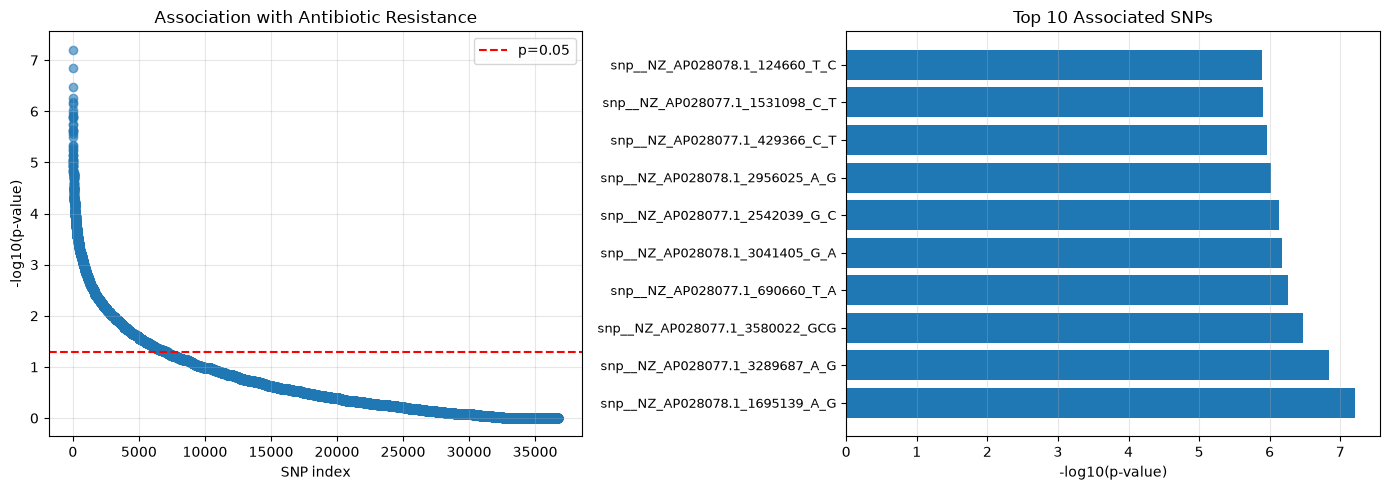

Plot saved!


In [22]:
# Plot top associated SNPs
top_snps = assoc_results.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Manhattan plot (SNPs by p-value)
axes[0].scatter(range(len(assoc_results)), -np.log10(assoc_results['p_value']), alpha=0.6)
axes[0].axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
axes[0].set_xlabel('SNP index')
axes[0].set_ylabel('-log10(p-value)')
axes[0].set_title('Association with Antibiotic Resistance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top SNPs
axes[1].barh(range(len(top_snps)), -np.log10(top_snps['p_value']))
axes[1].set_yticks(range(len(top_snps)))
axes[1].set_yticklabels([s[:30] for s in top_snps['SNP']], fontsize=9)
axes[1].set_xlabel('-log10(p-value)')
axes[1].set_title('Top 10 Associated SNPs')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'snp_associations_{target_antibiotic}.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved!")

In [24]:
# Feature statistics
print(f"\nFinal feature matrix statistics:")
print(f"\nAllele frequencies in final SNPs:")
final_prev = snps_final.sum(axis=0) / len(snps_final) * 100
print(f"  Mean: {final_prev.mean():.2f}%")
print(f"  Median: {final_prev.median():.2f}%")
print(f"  Range: {final_prev.min():.2f}% - {final_prev.max():.2f}%")

print(f"\nTarget distribution:")
print(f"  Resistant (R): {SXT_profile.sum()}")
print(f"  Susceptible (S): {(SXT_profile==0).sum()}")
print(f"  Balance: {SXT_profile.sum() / len(SXT_profile) * 100:.1f}% resistant")


Final feature matrix statistics:

Allele frequencies in final SNPs:
  Mean: 28.65%
  Median: 22.03%
  Range: 2.20% - 97.80%

Target distribution:
  Resistant (R): 123
  Susceptible (S): 104
  Balance: 54.2% resistant
